In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

In [2]:
univ_df=pd.read_excel("university.xlsx")

In [3]:
univ_df

,Univ,SAT,Top10,Accept,SFRatio,Expenses,GradRate
0,Brown,1310,89,22,13,22704,94
1,CalTech,1415,100,25,6,63575,81
2,CMU,1260,62,59,9,25026,72
3,Columbia,1310,76,24,12,31510,88
4,Cornell,1280,83,33,13,21864,90
5,Dartmouth,1340,89,23,10,32162,95
6,Duke,1315,90,30,12,31585,95
7,Georgetown,1255,74,24,12,20126,92
8,Harvard,1400,91,14,11,39525,97
9,JohnsHopkins,1305,75,44,7,58691,87


In [4]:
#values are not normal so we can go with normalization techniques

In [7]:
def normal_Func(i):
    x=i-i.min()/i.max()-i.min()
    return x

TypeError: unsupported operand type(s) for /: 'str' and 'str'

In [8]:
uni_normal_df=normal_Func(univ_df.iloc[:,1:])

In [12]:
# linked=sch.linkage(uni_normal_df,method='ward')

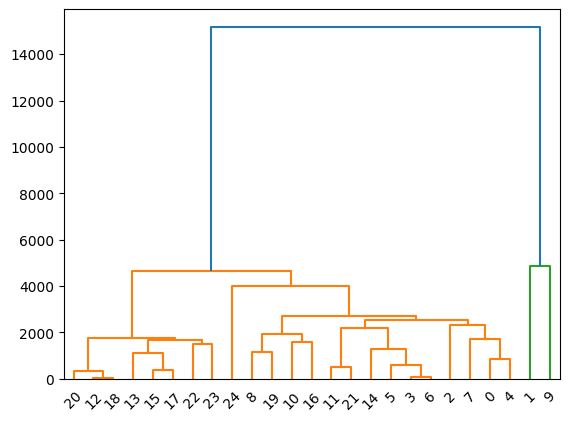

In [10]:
dendrogram=sch.dendrogram(sch.linkage(uni_normal_df))

In [8]:
hc=AgglomerativeClustering(n_clusters=5)

In [9]:
y=hc.fit_predict(uni_normal_df)

In [10]:
pip show scikit-learn

Name: scikit-learn
Version: 1.7.2
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License-Expression: BSD-3-Clause
Location: C:\Users\laksh\AppData\Local\Programs\Python\Python313\Lib\site-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: mlxtend
Note: you may need to restart the kernel to use updated packages.


In [11]:
y

array([4, 2, 1, 1, 4, 1, 1, 4, 3, 2, 3, 1, 0, 0, 1, 0, 3, 0, 0, 3, 0, 1,
       0, 0, 3])

In [12]:
univ_df["Cluster"]=y

In [13]:
univ_df

,Univ,SAT,Top10,Accept,SFRatio,Expenses,GradRate,Cluster
0,Brown,1310,89,22,13,22704,94,4
1,CalTech,1415,100,25,6,63575,81,2
2,CMU,1260,62,59,9,25026,72,1
3,Columbia,1310,76,24,12,31510,88,1
4,Cornell,1280,83,33,13,21864,90,4
5,Dartmouth,1340,89,23,10,32162,95,1
6,Duke,1315,90,30,12,31585,95,1
7,Georgetown,1255,74,24,12,20126,92,4
8,Harvard,1400,91,14,11,39525,97,3
9,JohnsHopkins,1305,75,44,7,58691,87,2


In [14]:
univ_df[univ_df['Cluster']==0]

,Univ,SAT,Top10,Accept,SFRatio,Expenses,GradRate,Cluster
12,NotreDame,1255,81,42,13,15122,94,0
13,PennState,1081,38,54,18,10185,80,0
15,Purdue,1005,28,90,19,9066,69,0
17,TexasA&M,1075,49,67,25,8704,67,0
18,UCBerkeley,1240,95,40,17,15140,78,0
20,UMichigan,1180,65,68,16,15470,85,0
22,UVA,1225,77,44,14,13349,92,0
23,UWisconsin,1085,40,69,15,11857,71,0


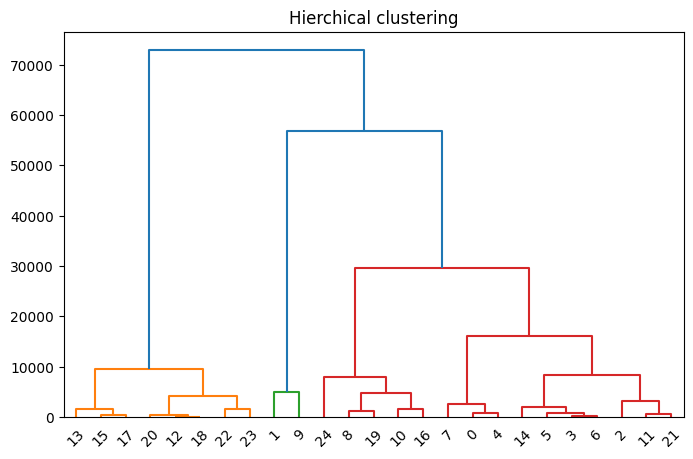

In [13]:
plt.figure(figsize=(8,5))
sch.dendrogram(linked)
plt.title("Hierchical clustering")
plt.show()